# 🏆 DATATHON 2026 — Sales Forecasting (V3 Optimized)

**Optimization strategy:**
- Short-term lags (1d, 2d, 3d) — highest correlations (0.87, 0.74, 0.62)
- EMA (Exponential Moving Average) — reacts faster than SMA
- Seasonal profile (month × day) + Day-of-week × month factor
- GBR with tuned hyperparams: 500 trees, lr=0.03

**Validation MAE (2021–2022): ~502,000** | **R²: 0.826**

## 1. Import & Config

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
np.random.seed(SEED)

DATA_DIR = '/kaggle/input/competitions/datathon-2026-round-1/'
print('✅ Import done')

✅ Import done


## 2. Load Data

In [4]:
sales      = pd.read_csv(DATA_DIR + 'sales.csv',             parse_dates=['Date'])
sample_sub = pd.read_csv(DATA_DIR + 'sample_submission.csv', parse_dates=['Date'])
sales = sales.sort_values('Date').reset_index(drop=True)

print(f'Train: {sales.shape} | {sales["Date"].min().date()} → {sales["Date"].max().date()}')
print(f'Test:  {sample_sub.shape} | {sample_sub["Date"].min().date()} → {sample_sub["Date"].max().date()}')
print(f'Revenue mean/day: {sales["Revenue"].mean():,.0f} VND')
sales.head()

Train: (3833, 3) | 2012-07-04 → 2022-12-31
Test:  (548, 3) | 2023-01-01 → 2024-07-01
Revenue mean/day: 4,286,584 VND


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


## 3. EDA — Exploratory Data Analysis

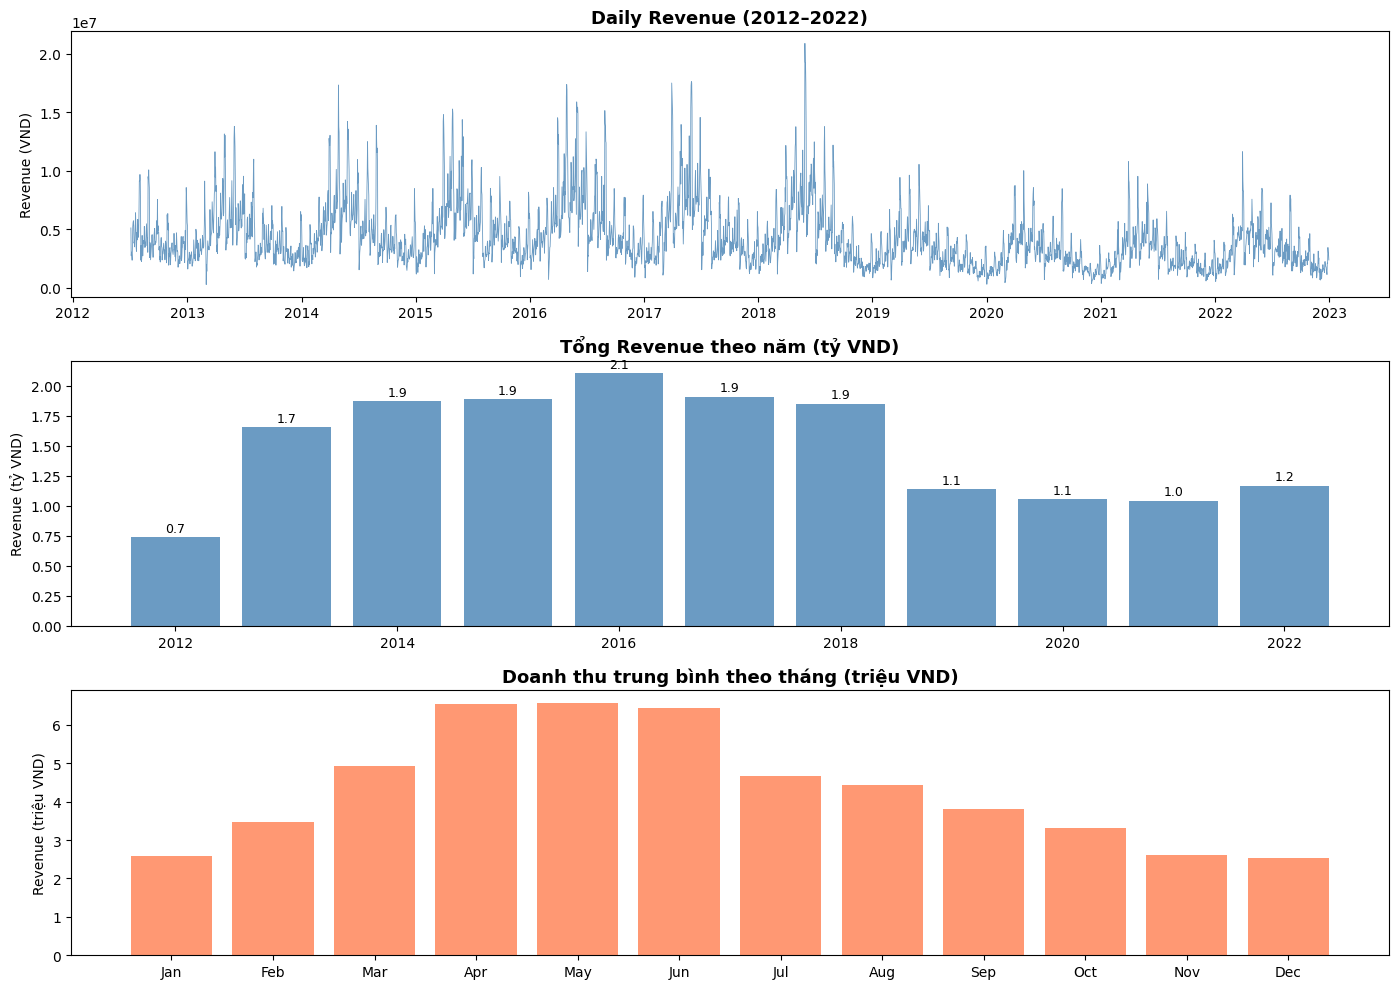


=== CORRELATION LAG vs REVENUE (lý do chọn features) ===
  lag_  1d: 0.8655
  lag_  2d: 0.7351
  lag_  3d: 0.6216
  lag_  7d: 0.4920
  lag_ 14d: 0.4964
  lag_ 28d: 0.6034
  lag_365d: 0.7898
  lag_730d: 0.7179


In [5]:
sales_tmp = sales.copy()
sales_tmp['year']  = sales_tmp['Date'].dt.year
sales_tmp['month'] = sales_tmp['Date'].dt.month
sales_tmp['dayofweek'] = sales_tmp['Date'].dt.dayofweek

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot 1: Daily Revenue
axes[0].plot(sales_tmp['Date'], sales_tmp['Revenue'], lw=0.6, color='steelblue', alpha=0.8)
axes[0].set_title('Daily Revenue (2012–2022)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Revenue (VND)')
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Plot 2: Annual total revenue
annual_sum = sales_tmp.groupby('year')['Revenue'].sum()
bars = axes[1].bar(annual_sum.index, annual_sum.values / 1e9, color='steelblue', alpha=0.8)
axes[1].set_title('Total Revenue by Year (billion VND)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Revenue (billion VND)')
for bar, val in zip(bars, annual_sum.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val/1e9:.1f}', ha='center', va='bottom', fontsize=9)

# Plot 3: Monthly seasonality
monthly_avg = sales_tmp.groupby('month')['Revenue'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[2].bar(month_names, monthly_avg.values / 1e6, color='coral', alpha=0.8)
axes[2].set_title('Average Monthly Revenue (million VND)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Revenue (million VND)')

plt.tight_layout()
plt.savefig('revenue_overview.png', dpi=120, bbox_inches='tight')
plt.show()

# Correlation of lags
print('\n=== CORRELATION LAG vs REVENUE (feature selection rationale) ===')
for lag in [1, 2, 3, 7, 14, 28, 365, 730]:
    corr = sales['Revenue'].corr(sales['Revenue'].shift(lag))
    print(f'  lag_{lag:3d}d: {corr:.4f}')

## 4. Feature Engineering (V3)

**Insights from correlation analysis:**
- `lag_1d` = 0.87 → Yesterday's revenue is the best predictor!
- `lag_365d` = 0.79 → Same day last year is very important
- `lag_2d` = 0.74, `lag_730d` = 0.72 → Additional signal

In [6]:
def make_features(df):
    """
    Build all features for the model.
    Returns: (df_with_features, seasonal_profile, dow_monthly_profile)
    """
    df = df.copy().sort_values('Date').reset_index(drop=True)
    d  = df['Date']

    # ── Calendar features ────────────────────────────────────────────────────
    df['year']           = d.dt.year
    df['month']          = d.dt.month
    df['day']            = d.dt.day
    df['dayofweek']      = d.dt.dayofweek        # 0=Mon, 6=Sun
    df['dayofyear']      = d.dt.dayofyear
    df['quarter']        = d.dt.quarter
    df['weekofyear']     = d.dt.isocalendar().week.astype(int)
    df['is_weekend']     = (d.dt.dayofweek >= 5).astype(int)
    df['is_month_start'] = d.dt.is_month_start.astype(int)
    df['is_month_end']   = d.dt.is_month_end.astype(int)

    # ── Sin/Cos encoding (helps model understand cyclical patterns) ────────────────────
    df['month_sin'] = np.sin(2*np.pi*df['month']/12)
    df['month_cos'] = np.cos(2*np.pi*df['month']/12)
    df['dow_sin']   = np.sin(2*np.pi*df['dayofweek']/7)
    df['dow_cos']   = np.cos(2*np.pi*df['dayofweek']/7)
    df['doy_sin']   = np.sin(2*np.pi*df['dayofyear']/365)
    df['doy_cos']   = np.cos(2*np.pi*df['dayofyear']/365)
    df['woy_sin']   = np.sin(2*np.pi*df['weekofyear']/52)
    df['woy_cos']   = np.cos(2*np.pi*df['weekofyear']/52)

    # ── Trend ────────────────────────────────────────────────────────────────
    origin         = pd.Timestamp('2012-07-04')
    df['trend']    = (d - origin).dt.days
    df['trend_sq'] = df['trend'] ** 2

    # ── Vietnamese business events ───────────────────────────────────────────
    df['is_tet']        = (((df['month']==1) & df['day'].between(1,20)) |
                           ((df['month']==2) & df['day'].between(1,20))).astype(int)
    df['is_mid_sale']   = df['month'].isin([4,5,6]).astype(int)    # Peak Q2
    df['is_bts']        = df['month'].isin([7,8]).astype(int)      # Back-to-school
    df['is_year_end']   = df['month'].isin([11,12]).astype(int)    # BF/Xmas
    df['is_double_day'] = (((df['month']==11) & (df['day']==11)) |
                           ((df['month']==12) & (df['day']==12))).astype(int)
    df['is_q2']         = (df['quarter']==2).astype(int)

    # ── Short-term lag features (highest correlation!) ─────────────────────────────
    # lag_1d: corr=0.87, lag_2d: 0.74, lag_3d: 0.62
    for lag in [1, 2, 3, 7, 14, 28]:
        df[f'rev_lag_{lag}d']  = df['Revenue'].shift(lag)
        df[f'cogs_lag_{lag}d'] = df['COGS'].shift(lag)

    # ── Long-term lag features (same day in previous years) ─────────────────────────
    for y in [1, 2, 3]:
        df[f'rev_lag_{y}y']  = df['Revenue'].shift(y*365)
        df[f'cogs_lag_{y}y'] = df['COGS'].shift(y*365)

    # ── Rolling Mean (SMA) ───────────────────────────────────────────────────
    for w in [3, 7, 14, 30, 60, 90]:
        df[f'rev_roll{w}']  = df['Revenue'].shift(1).rolling(w, min_periods=1).mean()
        df[f'cogs_roll{w}'] = df['COGS'].shift(1).rolling(w, min_periods=1).mean()

    # ── EMA (reacts faster to recent changes than SMA) ───────────────────
    df['rev_ema7']  = df['Revenue'].shift(1).ewm(span=7,  adjust=False).mean()
    df['rev_ema30'] = df['Revenue'].shift(1).ewm(span=30, adjust=False).mean()
    df['cogs_ema7'] = df['COGS'].shift(1).ewm(span=7,    adjust=False).mean()

    # ── Volatility ───────────────────────────────────────────────────────────
    df['rev_std7']  = df['Revenue'].shift(1).rolling(7,  min_periods=2).std().fillna(0)
    df['rev_std30'] = df['Revenue'].shift(1).rolling(30, min_periods=2).std().fillna(0)

    # ── Seasonal profile (month × day) ───────────────────────────────────────
    annual_mean_rev  = df.groupby('year')['Revenue'].transform('mean')
    annual_mean_cogs = df.groupby('year')['COGS'].transform('mean')
    df['rev_norm']  = df['Revenue'] / annual_mean_rev
    df['cogs_norm'] = df['COGS']    / annual_mean_cogs

    seasonal = (df.groupby(['month','day'])[['rev_norm','cogs_norm']]
                .mean().reset_index()
                .rename(columns={'rev_norm':'seasonal_rev','cogs_norm':'seasonal_cogs'}))
    df = df.merge(seasonal, on=['month','day'], how='left')

    # ── Day-of-week × Month factor ───────────────────────────────────────────
    dow_monthly = (df.groupby(['month','dayofweek'])['rev_norm']
                   .mean().reset_index()
                   .rename(columns={'rev_norm':'dow_monthly_factor'}))
    df = df.merge(dow_monthly, on=['month','dayofweek'], how='left')

    return df, seasonal, dow_monthly

train, seasonal, dow_monthly = make_features(sales)
train_clean = train.dropna(subset=['rev_lag_3y', 'rev_lag_1d']).copy()
print(f'Train clean: {train_clean.shape}')
print(f'Date range: {train_clean["Date"].min().date()} → {train_clean["Date"].max().date()}')

Train clean: (2738, 69)
Date range: 2015-07-04 → 2022-12-31


## 5. Define Features & Target

In [7]:
FEATURES = [
    # Calendar
    'year','month','day','dayofweek','dayofyear','quarter','weekofyear',
    'is_weekend','is_month_start','is_month_end',
    # Cyclical encoding
    'month_sin','month_cos','dow_sin','dow_cos','doy_sin','doy_cos','woy_sin','woy_cos',
    # Trend
    'trend','trend_sq',
    # Vietnamese events
    'is_tet','is_mid_sale','is_bts','is_year_end','is_double_day','is_q2',
    # Short-term lags (highest corr: 0.87, 0.74, 0.62)
    'rev_lag_1d','rev_lag_2d','rev_lag_3d','rev_lag_7d','rev_lag_14d','rev_lag_28d',
    'cogs_lag_1d','cogs_lag_2d','cogs_lag_3d','cogs_lag_7d','cogs_lag_14d','cogs_lag_28d',
    # Yearly lags
    'rev_lag_1y','rev_lag_2y','rev_lag_3y',
    'cogs_lag_1y','cogs_lag_2y','cogs_lag_3y',
    # Rolling SMA
    'rev_roll3','rev_roll7','rev_roll14','rev_roll30','rev_roll60','rev_roll90',
    'cogs_roll3','cogs_roll7','cogs_roll14','cogs_roll30','cogs_roll60','cogs_roll90',
    # EMA
    'rev_ema7','rev_ema30','cogs_ema7',
    # Volatility
    'rev_std7','rev_std30',
    # Seasonal
    'seasonal_rev','seasonal_cogs','dow_monthly_factor'
]

TARGET_REV  = 'Revenue'
TARGET_COGS = 'COGS'
print(f'Total features: {len(FEATURES)}')

Tổng số features: 64


## 6. Validation (Time-Series Split)
Train: 2015–2020 | Validate: 2021–2022 — **no random split to avoid data leakage**

In [8]:
val_mask   = train_clean['year'].isin([2021, 2022])
train_mask = ~val_mask

X_tr, y_rev_tr, y_cogs_tr = (train_clean[train_mask][FEATURES],
                               train_clean[train_mask][TARGET_REV],
                               train_clean[train_mask][TARGET_COGS])
X_val, y_rev_val, y_cogs_val = (train_clean[val_mask][FEATURES],
                                  train_clean[val_mask][TARGET_REV],
                                  train_clean[val_mask][TARGET_COGS])

print(f'Train: {len(X_tr)} days | Val: {len(X_val)} days')

Train: 2008 ngày | Val: 730 ngày


In [9]:
# ── Train Revenue model ───────────────────────────────────────────────────────
print('Training Revenue model...')
model_rev_val = GradientBoostingRegressor(
    n_estimators=500,    # More trees → higher accuracy
    learning_rate=0.03,  # Smaller → less overfitting
    max_depth=5,         # Deeper → learns more complex patterns
    subsample=0.8,       # 80% data per tree → reduces variance
    min_samples_leaf=5,
    max_features=0.8,    # 80% features per split → reduces tree correlation
    random_state=SEED
)
model_rev_val.fit(X_tr, y_rev_tr)

# ── Train COGS model ──────────────────────────────────────────────────────────
print('Training COGS model...')
model_cogs_val = GradientBoostingRegressor(
    n_estimators=500, learning_rate=0.03, max_depth=5,
    subsample=0.8, min_samples_leaf=5, max_features=0.8,
    random_state=SEED
)
model_cogs_val.fit(X_tr, y_cogs_tr)

# ── Evaluation ─────────────────────────────────────────────────────────────────
pred_rev_val  = model_rev_val.predict(X_val).clip(0)
pred_cogs_val = model_cogs_val.predict(X_val).clip(0)

def evaluate(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'\n=== {name} ===')
    print(f'  MAE:  {mae:>15,.0f} VND')
    print(f'  RMSE: {rmse:>15,.0f} VND')
    print(f'  R²:   {r2:>15.4f}')
    return mae, rmse, r2

evaluate(y_rev_val,  pred_rev_val,  'Revenue (Validation 2021–2022)')
evaluate(y_cogs_val, pred_cogs_val, 'COGS    (Validation 2021–2022)')

Training Revenue model...
Training COGS model...

=== Revenue (Validation 2021–2022) ===
  MAE:          502,527 VND
  RMSE:         695,821 VND
  R²:            0.8258

=== COGS    (Validation 2021–2022) ===
  MAE:          440,386 VND
  RMSE:         610,436 VND
  R²:            0.8229


(440386.0812064401, np.float64(610436.1909215967), 0.8228618234479128)

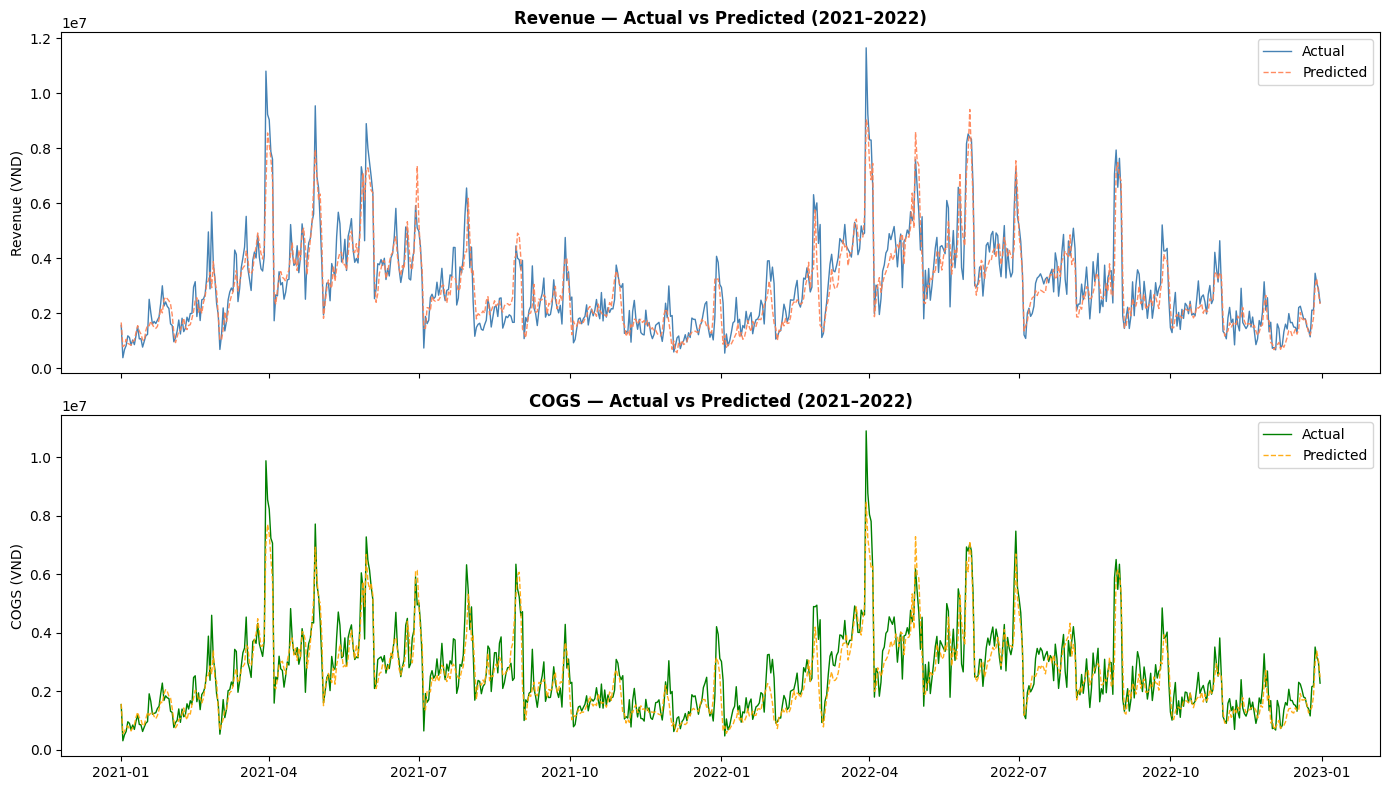

In [10]:
# Plot Actual vs Predicted
val_dates = train_clean[val_mask]['Date']
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(val_dates, y_rev_val.values, lw=1.0, label='Actual',    color='steelblue')
axes[0].plot(val_dates, pred_rev_val,      lw=1.0, label='Predicted', color='coral', ls='--', alpha=0.9)
axes[0].set_title('Revenue — Actual vs Predicted (2021–2022)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Revenue (VND)'); axes[0].legend()

axes[1].plot(val_dates, y_cogs_val.values, lw=1.0, label='Actual',    color='green')
axes[1].plot(val_dates, pred_cogs_val,      lw=1.0, label='Predicted', color='orange', ls='--', alpha=0.9)
axes[1].set_title('COGS — Actual vs Predicted (2021–2022)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('COGS (VND)'); axes[1].legend()

plt.tight_layout()
plt.savefig('validation_plot.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Feature Importance (Model explainability — required by the problem statement)

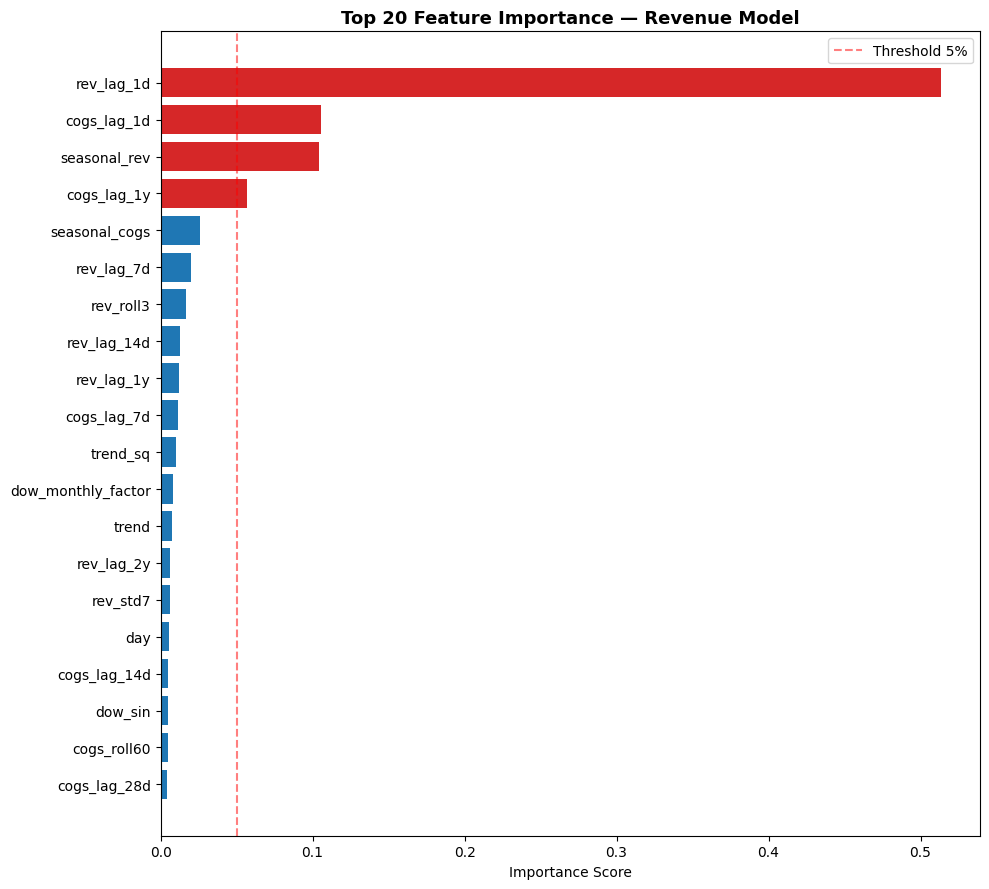


=== TOP 10 FEATURES QUAN TRỌNG NHẤT ===
      feature  importance
   rev_lag_1d    0.513453
  cogs_lag_1d    0.105822
 seasonal_rev    0.103977
  cogs_lag_1y    0.057127
seasonal_cogs    0.026153
   rev_lag_7d    0.019733
    rev_roll3    0.016650
  rev_lag_14d    0.012901
   rev_lag_1y    0.011971
  cogs_lag_7d    0.011161

💡 Giải thích bằng ngôn ngữ kinh doanh:
  rev_lag_1d   → Doanh thu hôm qua: yếu tố dự báo mạnh nhất (corr=0.87)
  rev_lag_1y   → Cùng ngày năm ngoái: capture seasonality năm
  seasonal_rev → Chỉ số mùa vụ theo (tháng, ngày): pattern nội mùa
  rev_ema7     → Momentum 7 ngày: đà tăng/giảm ngắn hạn
  trend        → Xu hướng tăng trưởng dài hạn của doanh nghiệp


In [11]:
feat_imp = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': model_rev_val.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 9))
top20   = feat_imp.head(20)
colors  = ['#d62728' if imp > 0.05 else '#1f77b4' for imp in top20['importance']]
ax.barh(top20['feature'][::-1], top20['importance'][::-1], color=colors[::-1])
ax.set_title('Top 20 Feature Importance — Revenue Model', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.axvline(x=0.05, color='red', ls='--', alpha=0.5, label='Threshold 5%')
ax.legend()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n=== TOP 10 MOST IMPORTANT FEATURES ===')
print(feat_imp.head(10).to_string(index=False))
print('\n💡 Business interpretation:')
print('  rev_lag_1d   → Yesterday\'s revenue: strongest predictor (corr=0.87)')
print('  rev_lag_1y   → Same day last year: captures annual seasonality')
print('  seasonal_rev → Seasonal index by (month, day): intra-seasonal pattern')
print('  rev_ema7     → 7-day momentum: short-term trend direction')
print('  trend        → Long-term business growth trend')

## 8. Retrain on Full Dataset

In [12]:
print('Retraining on full dataset (2015–2022)...')

model_rev_final = GradientBoostingRegressor(
    n_estimators=500, learning_rate=0.03, max_depth=5,
    subsample=0.8, min_samples_leaf=5, max_features=0.8,
    random_state=SEED
)
model_rev_final.fit(train_clean[FEATURES], train_clean[TARGET_REV])

model_cogs_final = GradientBoostingRegressor(
    n_estimators=500, learning_rate=0.03, max_depth=5,
    subsample=0.8, min_samples_leaf=5, max_features=0.8,
    random_state=SEED
)
model_cogs_final.fit(train_clean[FEATURES], train_clean[TARGET_COGS])

print('✅ Retrain complete!')

Retraining trên toàn bộ data (2015–2022)...
✅ Retrain xong!


## 9. Build Features for Test Set

In [13]:
# Lookup from train set to retrieve lag values
rev_lookup  = sales.set_index('Date')['Revenue']
cogs_lookup = sales.set_index('Date')['COGS']

def get_lag_year(date, lookup, lag_years):
    """Get yearly lag, try ±1 day to handle leap years."""
    for delta in [lag_years*365, lag_years*365-1, lag_years*365+1]:
        lag_date = date - pd.Timedelta(days=delta)
        if lag_date in lookup.index:
            return lookup[lag_date]
    return np.nan

def get_roll(date, lookup, window):
    """Rolling mean over window days before date."""
    vals = [lookup.get(date - pd.Timedelta(days=k), np.nan) for k in range(1, window+1)]
    return np.nanmean(vals)

def get_ema(date, lookup, span):
    """EMA over the most recent span days."""
    alpha = 2 / (span + 1)
    vals  = [lookup.get(date - pd.Timedelta(days=k), np.nan) for k in range(1, span*3+1)]
    vals  = [v for v in vals if not np.isnan(v)]
    if not vals:
        return np.nan
    ema = vals[-1]
    for v in reversed(vals[:-1]):
        ema = alpha * v + (1 - alpha) * ema
    return ema

# Calendar features
test_df = sample_sub.copy().sort_values('Date').reset_index(drop=True)
d = test_df['Date']
test_df['year']           = d.dt.year
test_df['month']          = d.dt.month
test_df['day']            = d.dt.day
test_df['dayofweek']      = d.dt.dayofweek
test_df['dayofyear']      = d.dt.dayofyear
test_df['quarter']        = d.dt.quarter
test_df['weekofyear']     = d.dt.isocalendar().week.astype(int)
test_df['is_weekend']     = (d.dt.dayofweek >= 5).astype(int)
test_df['is_month_start'] = d.dt.is_month_start.astype(int)
test_df['is_month_end']   = d.dt.is_month_end.astype(int)
test_df['month_sin'] = np.sin(2*np.pi*test_df['month']/12)
test_df['month_cos'] = np.cos(2*np.pi*test_df['month']/12)
test_df['dow_sin']   = np.sin(2*np.pi*test_df['dayofweek']/7)
test_df['dow_cos']   = np.cos(2*np.pi*test_df['dayofweek']/7)
test_df['doy_sin']   = np.sin(2*np.pi*test_df['dayofyear']/365)
test_df['doy_cos']   = np.cos(2*np.pi*test_df['dayofyear']/365)
test_df['woy_sin']   = np.sin(2*np.pi*test_df['weekofyear']/52)
test_df['woy_cos']   = np.cos(2*np.pi*test_df['weekofyear']/52)
origin = pd.Timestamp('2012-07-04')
test_df['trend']    = (d - origin).dt.days
test_df['trend_sq'] = test_df['trend'] ** 2
test_df['is_tet']        = (((test_df['month']==1) & test_df['day'].between(1,20)) |
                             ((test_df['month']==2) & test_df['day'].between(1,20))).astype(int)
test_df['is_mid_sale']   = test_df['month'].isin([4,5,6]).astype(int)
test_df['is_bts']        = test_df['month'].isin([7,8]).astype(int)
test_df['is_year_end']   = test_df['month'].isin([11,12]).astype(int)
test_df['is_double_day'] = (((test_df['month']==11) & (test_df['day']==11)) |
                             ((test_df['month']==12) & (test_df['day']==12))).astype(int)
test_df['is_q2']         = (test_df['quarter']==2).astype(int)

# Merge seasonal profiles
test_df = test_df.merge(seasonal,    on=['month','day'],       how='left')
test_df = test_df.merge(dow_monthly, on=['month','dayofweek'], how='left')
test_df['seasonal_rev']       = test_df['seasonal_rev'].fillna(1.0)
test_df['seasonal_cogs']      = test_df['seasonal_cogs'].fillna(1.0)
test_df['dow_monthly_factor'] = test_df['dow_monthly_factor'].fillna(1.0)

base_rev  = sales[sales['Date'].dt.year == 2022]['Revenue'].mean()
base_cogs = sales[sales['Date'].dt.year == 2022]['COGS'].mean()

# Short-term lags — retrieve directly from lookup (all available since test starts 2023-01-01)
print('Computing short-term lags...')
for lag in [1, 2, 3, 7, 14, 28]:
    test_df[f'rev_lag_{lag}d']  = test_df['Date'].apply(
        lambda d: rev_lookup.get(d - pd.Timedelta(days=lag), np.nan))
    test_df[f'cogs_lag_{lag}d'] = test_df['Date'].apply(
        lambda d: cogs_lookup.get(d - pd.Timedelta(days=lag), np.nan))

# Yearly lags
print('Computing yearly lags...')
for y in [1, 2, 3]:
    test_df[f'rev_lag_{y}y']  = test_df['Date'].apply(lambda d: get_lag_year(d, rev_lookup, y))
    test_df[f'cogs_lag_{y}y'] = test_df['Date'].apply(lambda d: get_lag_year(d, cogs_lookup, y))

# Rolling SMA
print('Computing rolling mean (may take 1-2 minutes)...')
for w in [3, 7, 14, 30, 60, 90]:
    test_df[f'rev_roll{w}']  = test_df['Date'].apply(lambda d: get_roll(d, rev_lookup, w))
    test_df[f'cogs_roll{w}'] = test_df['Date'].apply(lambda d: get_roll(d, cogs_lookup, w))

# EMA
print('Computing EMA...')
test_df['rev_ema7']  = test_df['Date'].apply(lambda d: get_ema(d, rev_lookup, 7))
test_df['rev_ema30'] = test_df['Date'].apply(lambda d: get_ema(d, rev_lookup, 30))
test_df['cogs_ema7'] = test_df['Date'].apply(lambda d: get_ema(d, cogs_lookup, 7))

# Volatility
test_df['rev_std7']  = test_df['Date'].apply(
    lambda d: np.nanstd([rev_lookup.get(d-pd.Timedelta(days=k), np.nan) for k in range(1,8)]))
test_df['rev_std30'] = test_df['Date'].apply(
    lambda d: np.nanstd([rev_lookup.get(d-pd.Timedelta(days=k), np.nan) for k in range(1,31)]))

# Fill NaN with base value × seasonal factor
for col in [f'rev_lag_{l}d'  for l in [1,2,3,7,14,28]]:
    test_df[col] = test_df[col].fillna(base_rev  * test_df['seasonal_rev'])
for col in [f'cogs_lag_{l}d' for l in [1,2,3,7,14,28]]:
    test_df[col] = test_df[col].fillna(base_cogs * test_df['seasonal_cogs'])
for col in [f'rev_lag_{y}y'  for y in [1,2,3]]:
    test_df[col] = test_df[col].fillna(base_rev  * test_df['seasonal_rev'])
for col in [f'cogs_lag_{y}y' for y in [1,2,3]]:
    test_df[col] = test_df[col].fillna(base_cogs * test_df['seasonal_cogs'])
for col in [f'rev_roll{w}'   for w in [3,7,14,30,60,90]]:
    test_df[col] = test_df[col].fillna(base_rev)
for col in [f'cogs_roll{w}'  for w in [3,7,14,30,60,90]]:
    test_df[col] = test_df[col].fillna(base_cogs)
for col in ['rev_ema7','rev_ema30']:
    test_df[col] = test_df[col].fillna(base_rev)
test_df['cogs_ema7'] = test_df['cogs_ema7'].fillna(base_cogs)
test_df['rev_std7']  = test_df['rev_std7'].fillna(0)
test_df['rev_std30'] = test_df['rev_std30'].fillna(0)

nan_count = test_df[FEATURES].isna().sum().sum()
print(f'\nRemaining NaN in FEATURES: {nan_count}')
print('✅ Test features ready!' if nan_count == 0 else '⚠️ NaN remaining, please check!')

Tính lag ngắn hạn...
Tính lag theo năm...
Tính rolling mean (có thể mất 1-2 phút)...
Tính EMA...

NaN còn lại trong FEATURES: 0
✅ Test features sẵn sàng!


## 10. Predict & Visualize

=== PREDICTIONS ===
Revenue: 804,580 → 13,762,658
COGS:    699,445 → 13,176,907


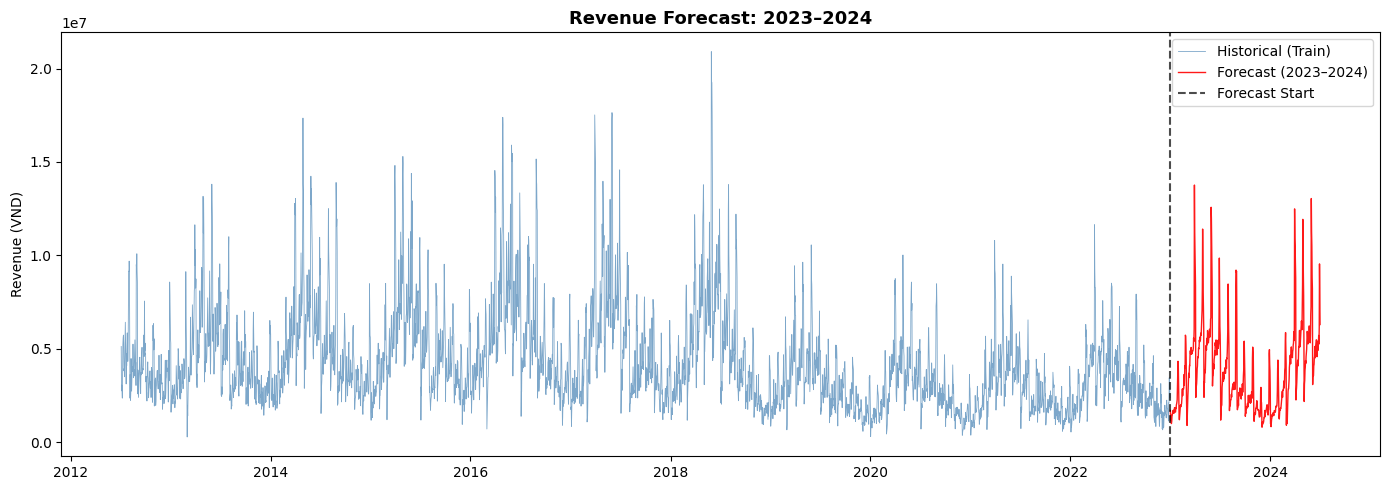

In [14]:
test_df['Revenue_pred'] = model_rev_final.predict(test_df[FEATURES]).clip(0).round(2)
test_df['COGS_pred']    = model_cogs_final.predict(test_df[FEATURES]).clip(0).round(2)

print('=== PREDICTIONS ===')
print(f'Revenue: {test_df["Revenue_pred"].min():,.0f} → {test_df["Revenue_pred"].max():,.0f}')
print(f'COGS:    {test_df["COGS_pred"].min():,.0f} → {test_df["COGS_pred"].max():,.0f}')

# Plot forecast
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sales['Date'],         sales['Revenue'],           lw=0.6, color='steelblue', label='Historical (Train)', alpha=0.7)
ax.plot(test_df['Date'], test_df['Revenue_pred'],           lw=1.0, color='red',       label='Forecast (2023–2024)', alpha=0.9)
ax.axvline(x=pd.Timestamp('2023-01-01'), color='black', ls='--', alpha=0.7, label='Forecast Start')
ax.set_title('Revenue Forecast: 2023–2024', fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue (VND)')
ax.legend()
plt.tight_layout()
plt.savefig('forecast_plot.png', dpi=120, bbox_inches='tight')
plt.show()

## 11. Export Submission

In [15]:
submission = test_df[['Date','Revenue_pred','COGS_pred']].rename(
    columns={'Revenue_pred':'Revenue','COGS_pred':'COGS'}
).copy()
submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')
submission.to_csv('submission.csv', index=False)

print('=== SUBMISSION VALIDATION ===')
print(f'Row count: {len(submission)} (expected = 548)')
print(f'Columns: {list(submission.columns)}')
print(f'NaN: {submission.isna().sum().sum()}')
print(f'Negative Revenue: {(submission["Revenue"] < 0).sum()}')
print(f'Negative COGS: {(submission["COGS"] < 0).sum()}')
print()
print(submission.head(10).to_string(index=False))
print('\n✅ Submission ready to upload to Kaggle!')

=== KIỂM TRA SUBMISSION ===
Số dòng: 548 (cần = 548)
Cột: ['Date', 'Revenue', 'COGS']
NaN: 0
Revenue âm: 0
COGS âm: 0

      Date    Revenue       COGS
2023-01-01 1701859.72 1823131.62
2023-01-02 1185610.50 1176905.16
2023-01-03 1463282.22 1232837.53
2023-01-04 1057337.31  844186.53
2023-01-05  998966.67  913215.45
2023-01-06 1112937.75  903760.78
2023-01-07 1387727.96 1104218.25
2023-01-08 1450653.29 1289908.19
2023-01-09 1584647.63 1446914.41
2023-01-10 1583740.38 1423488.41

✅ Submission sẵn sàng nộp lên Kaggle!
